In [1]:
from aicsimageio import AICSImage
from aicsimageio.readers import BioformatsReader

import matplotlib.pyplot as plt
from PIL import Image

In [4]:
img = AICSImage(
    "/Volumes/scratch/Promotion/02_Experiments/00_microscale_micrographs/Pyrofil/245/245_004-4.vsi",
    reader=BioformatsReader,          # <- force Bio-Formats
    reconstruct_mosaic=False
)

print(img.dims)                       # e.g. TCZYX
data = img.get_image_dask_data("TCZYX")
print(data.shape)

# Example: get one 2D slice as NumPy

# take the only T, C, Z index
img2d = data[0, 0, 0]      # shape (Y, X) as dask array
img2d = img2d.compute()    # convert to NumPy
print(img2d.shape, img2d.dtype)

<Dimensions [T: 1, C: 1, Z: 1, Y: 1129, X: 13828]>
(1, 1, 1, 1129, 13828)
(1129, 13828) uint8


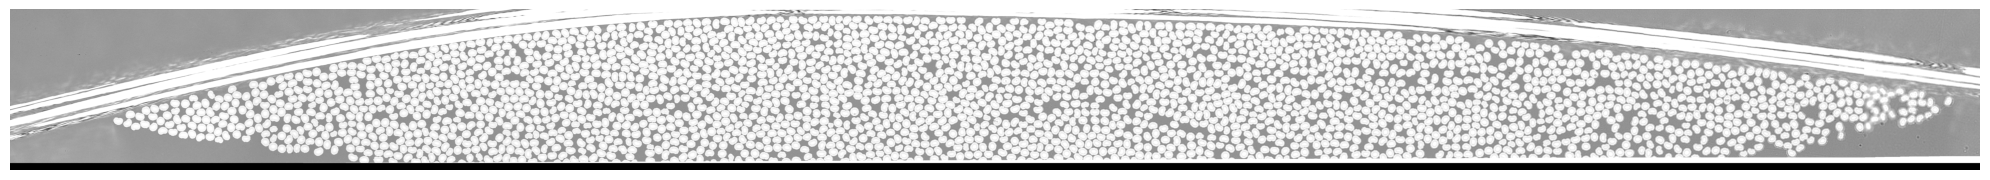

In [5]:

plt.figure(figsize=(20, 4))
plt.imshow(img2d, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

Image.fromarray(img2d).save("vsi_slice.tiff")

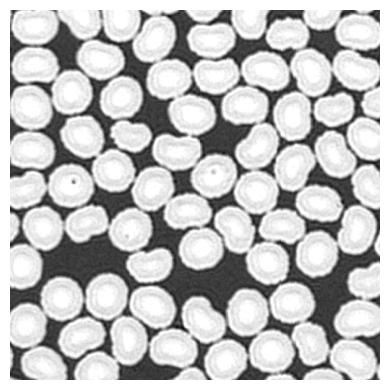

uint8 (512, 512)


In [13]:
x0, y0 = 2500, 400
w, h = 512, 512

slice = img2d[y0:y0+h, x0:x0+w]


plt.figure(figsize=(4, 4))
plt.imshow(slice, cmap="grey")
plt.axis("off")
plt.tight_layout()
plt.show()

print(slice.dtype, slice.shape)

Image.fromarray(slice).save("245_004-4_slice-2500-400.tiff")